# Importing Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import rasterio

# Load and Structure Dataset

## Import dataset

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Agri_RS_AI_Project/03_Phase_1_5_Validation_Layer_&_Time_Series_Entry/python_validation/5_Time_Series_Engine/data/ndvi_timeseries.csv")

## Convert Date Column, Sort Time and Set Time Index

In [7]:
sys.path.append('/content/drive/MyDrive/Agri_RS_AI_Project')
from src.time_processing import prepare_time_index

df = prepare_time_index(df)

## Droping the Extra Column

In [9]:
df = df.drop(
    columns=['system:index', '.geo'],
    errors='ignore'
    )

# Irregular Sampling

In [10]:
df.index.to_series().diff()

,date
date,
2024-01-04,NaT
2024-01-29,25 days
2024-02-03,5 days
2024-02-18,15 days
2024-02-23,5 days
2024-02-28,5 days
2024-03-09,10 days
2024-03-14,5 days
2024-04-13,30 days


# Resample Time Series

In [11]:
df_15 = df.resample('15D').mean()
df_15['NDVI'] = df_15['NDVI'].interpolate(method='time') #Or you can just leave it.

7 days has too many NaN and 30 days few Observation. That's why15 days is selected .

# Visualize NDVI Curve

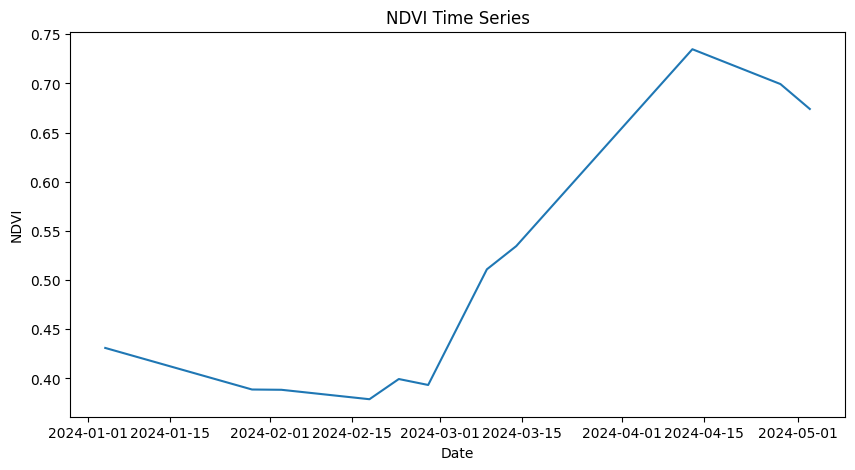

In [12]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df['NDVI'])

plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title("NDVI Time Series")

plt.show()

# Noise Spike Detection

In [13]:
df['change'] = df['NDVI'].diff()
spikes = df[abs(df['change']) > 0.3]

In [14]:
spikes

,NDVI,change
date,,


Hare in my case I don't have any spike. So, I don't need to perform any smoothing process. will learn this in next module.